In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [7]:
script_dir = os.getcwd()
chicago_path = os.path.join(script_dir, '..', 'Data', 'Data Integration', '11.16_Chicago_Inspections_Reduced.csv')
newYork_path = os.path.join(script_dir, '..', 'Data', 'Data Integration', '11.16_NYC_Inspections_Reduced.csv')
integrated_path = os.path.join(script_dir, '..', 'Data', 'Data Integration', '11.16_Inspections_Reduced.csv')

chicago = pd.read_csv(chicago_path)
nyc = pd.read_csv(newYork_path)
integrated = pd.read_csv(integrated_path)

# Question 1
## How do restaurant inspection outcomes (NYC’s grades vs. Chicago’s results) compare in terms of failure rate across years?

In [8]:
integrated.head()

,RecordID,DBA Name,CAMIS,License #,Address,Street,City,Boro,State,Zip,Inspection Date,Risk,Critical Flag,Facility Type,Cuisine Description,Violations,Results
0,174415,THEATER WIT NFP,NaN,2037878.0,1229 W BELMONT AVE,NaN,CHICAGO,NaN,IL,60657.0,2010-07-01T00:00:00Z,Risk 3 (Low),NaN,Restaurant,NaN,21. * CERTIFIED FOOD MANAGER ON SITE WHEN POTE...,Fail
1,182294,"WEST TOWN DAYCARE ,LLC",NaN,2570038.0,2751 W CORTEZ ST,NaN,CHICAGO,NaN,IL,60622.0,2019-07-25T00:00:00Z,Risk 1 (High),NaN,1023 CHILDERN'S SERVICES FACILITY,NaN,NaN,Pass
2,171418,CHILDREN'S HOME AND AID SOCIETY OF ILLINOIS,NaN,2215528.0,1701 W 63RD ST,NaN,CHICAGO,NaN,IL,60636.0,2023-04-21T00:00:00Z,Risk 1 (High),NaN,Daycare Above and Under 2 Years,NaN,NaN,No Entry
3,73133,MCLOUGHLIN'S,40587835.0,NaN,NaN,BROADWAY,NEW YORK CITY,Queens,NY,11106.0,2024-05-23T00:00:00Z,NaN,Critical,NaN,Irish,"FOOD CONTACT SURFACE NOT PROPERLY WASHED, RINS...",NaN
4,21130,REX,50125902.0,NaN,NaN,10 AVENUE,NEW YORK CITY,Manhattan,NY,10019.0,2024-11-21T00:00:00Z,NaN,Critical,NaN,Coffee/Tea,EVIDENCE OF RATS OR LIVE RATS IN ESTABLISHMENT...,NaN


In [33]:
chicago['Results'].unique()

array(['Out of Business', 'Fail', 'Pass', 'Pass w/ Conditions',
       'No Entry', 'Not Ready', 'Business Not Located'], dtype=object)

In [48]:
print(f"Business Not Located Results: {round(len(chicago[chicago.Results == 'Business Not Located']) / len(chicago) * 100, 2)}%")
print(f"Not Ready Results: {round(len(chicago[chicago.Results == 'Not Ready']) / len(chicago) * 100, 2)}%")
print(f"No Entry Results: {round(len(chicago[chicago.Results == 'No Entry']) / len(chicago) * 100, 2)}%")
print(f"Out of Business Results: {round(len(chicago[chicago.Results == 'Out of Business']) / len(chicago) * 100, 2)}%")

Business Not Located Results: 0.03%
Not Ready Results: 1.37%
No Entry Results: 4.48%
Out of Business Results: 8.34%


## For this question, in the chicago dataset, we can disregard Results listed as Business Not Located, Not Ready, No Entry, and Out of Business

In [49]:
chicagoFiltered = chicago[~chicago.Results.isin(['Business Not Located', 'Not Ready', 'No Entry', 'Out of Business'])]

In [52]:
nyc['Critical Flag'].unique()

array(['Critical', 'Not Critical', 'Not Applicable'], dtype=object)

In [67]:
print(f"Not Applicable Results: {round(len(nyc[nyc["Critical Flag"] == 'Not Applicable']) / len(nyc) * 100, 2)}%")

Not Applicable Results: 1.41%


## For this question, in the NYC dataset, we can disregard Critical Flags/Results listed as Not Applicable
### We are treating Critical Flag column as the same as the Results column in the Chicago dataset

In [58]:
nycFiltered = nyc[nyc['Critical Flag'].isin(['Critical', 'Not Critical'])]

In [65]:
chicagoFiltered['Year'] = pd.to_datetime(chicagoFiltered['Inspection Date']).dt.year
nycFiltered['Year'] = pd.to_datetime(nycFiltered['Inspection Date']).dt.year

chicagoFiltered['Pass Y/N'] = chicagoFiltered['Results'].apply(lambda x: 'Y' if 'Pass' in x else 'N')
nycFiltered['Pass Y/N'] = nycFiltered['Critical Flag'].apply(lambda x: 'N' if 'Not' in x else 'Y')

/var/folders/m3/6k1m3_dj6p57d919qhpcl2z80000gn/T/ipykernel_82562/2550913292.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chicagoFiltered['Year'] = pd.to_datetime(chicagoFiltered['Inspection Date']).dt.year
/var/folders/m3/6k1m3_dj6p57d919qhpcl2z80000gn/T/ipykernel_82562/2550913292.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nycFiltered['Year'] = pd.to_datetime(nycFiltered['Inspection Date']).dt.year
/var/folders/m3/6k1m3_dj6p57d919qhpcl2z80000gn/T/ipykernel_82562/2550913292.py:4: SettingWithC

In [83]:
chicagoPassProp = chicagoFiltered[['Year', 'Pass Y/N']].groupby('Year').value_counts(normalize = True).reset_index()[['Year', 'proportion']]
nycPassProp = nycFiltered[['Year', 'Pass Y/N']].groupby('Year').value_counts(normalize = True).reset_index()[['Year', 'proportion']]

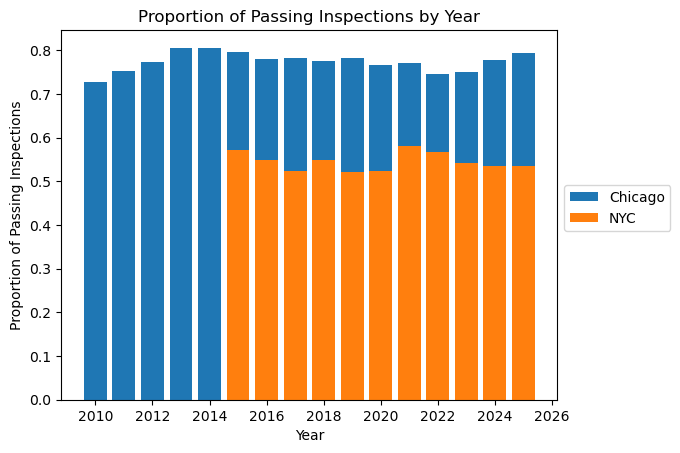

In [ ]:
plt.bar(chicagoPassProp['Year'], chicagoPassProp['proportion'], label='Chicago')
plt.bar(nycPassProp['Year'], nycPassProp['proportion'], label='NYC')

plt.title('Proportion of Passing Inspections by Year')
plt.xlabel('Year')
plt.ylabel('Proportion of Passing Inspections')

plt.legend(loc = 'upper left', bbox_to_anchor=(1, .6))
plt.show()

# Question 2
## How have average inspection scores (NYC) and pass rates (Chicago) changed from 2015–2025?
### We can answer this question following the same logic as the previous question
### We will use the same filtered data but just add more detail by filtering by year-month instead of only year; filter year after 2015

In [165]:
chicagoFiltered = chicagoFiltered[chicagoFiltered.Year >= 2015]
nycFiltered = nycFiltered[nycFiltered.Year >= 2015]

In [166]:
chicagoFiltered.loc[:, 'YearMonth'] = pd.to_datetime(chicagoFiltered.loc[:, 'Inspection Date']).dt.to_period('M')
nycFiltered.loc[:, 'YearMonth'] = pd.to_datetime(nycFiltered.loc[:, 'Inspection Date']).dt.to_period('M')

/var/folders/m3/6k1m3_dj6p57d919qhpcl2z80000gn/T/ipykernel_82562/3547936164.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  chicagoFiltered.loc[:, 'YearMonth'] = pd.to_datetime(chicagoFiltered.loc[:, 'Inspection Date']).dt.to_period('M')
/var/folders/m3/6k1m3_dj6p57d919qhpcl2z80000gn/T/ipykernel_82562/3547936164.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  nycFiltered.loc[:, 'YearMonth'] = pd.to_datetime(nycFiltered.loc[:, 'Inspection Date']).dt.to_period('M')


In [167]:
chicagoPassPropYM = chicagoFiltered[['YearMonth', 'Pass Y/N']].groupby(['YearMonth']).value_counts(normalize=True).reset_index()
nycPassPropYM = nycFiltered[['YearMonth', 'Pass Y/N']].groupby(['YearMonth']).value_counts(normalize=True).reset_index()

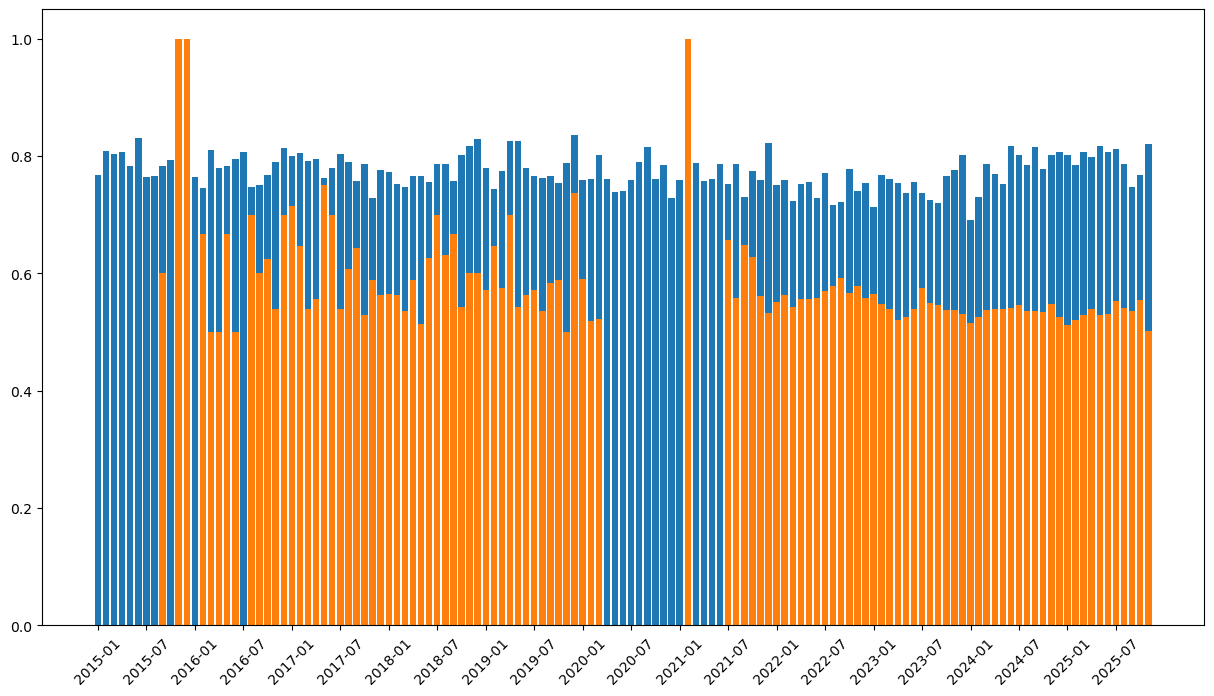

In [ ]:
fig, ax = plt.subplots(figsize = (15, 8))
plt.bar(chicagoPassPropYM['YearMonth'].astype(str), chicagoPassPropYM['proportion'], label='Chicago')
plt.bar(nycPassPropYM['YearMonth'].astype(str), nycPassPropYM['proportion'], label='Chicago')

plt.xticks(chicagoPassPropYM['YearMonth'].astype('str')[::12], rotation=45)
plt.title('Proportion of Passing Inspections by Year-Month')
plt.xlabel('Year-Month')
plt.ylabel('Proportion of Passing Inspections')
plt.legend(loc = 'upper left', bbox_to_anchor=(1, .6))
plt.show()